In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

A**C**C&emsp;&emsp;и&emsp;&emsp;A**C**C<br>
T**T**G&emsp;&emsp;и&emsp;&emsp;T**G**G

In [2]:
#  размерность - kcal/mol
G_GCG_CTC  = 1.02 * 4184 / (6.02 * 10**23)# Table 3 из статьи (2) с переводом в Дж

# G_ACC_TGG = G_AC_TG + G_CC_GG
G_GCG_CGC = (-2.24 - 2.17) * 4184 / (6.02 * 10**23)# Table 1 из статьи (1) с переводом в Дж

delta_mismatch = G_GCG_CTC - G_GCG_CGC
print(f"Разница между двойной спиралью с мисмэтчем и без него равна {delta_mismatch} Дж")

Разница между двойной спиралью с мисмэтчем и без него равна 3.773940199335549e-20 Дж


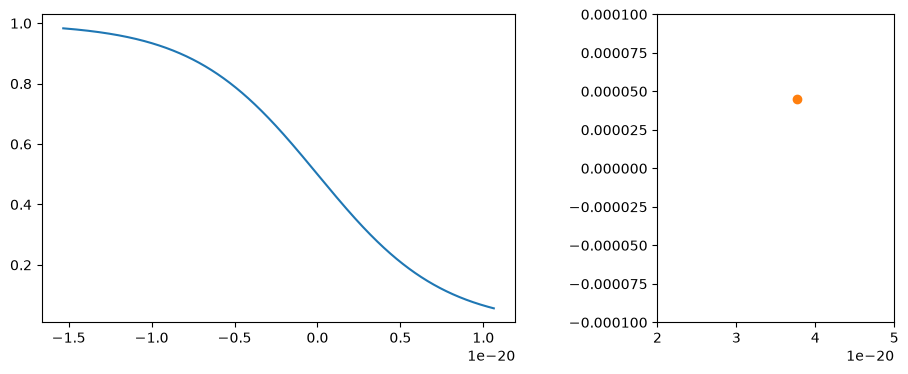

In [3]:
const = 1/(1.380649*(10**(-23))*273)
data = np.linspace(G_GCG_CGC-0.5*G_GCG_CGC, G_GCG_CTC + 0.5*G_GCG_CTC, 10000)
def func(x):
    return np.exp(-x*const)/(1 + np.exp(-x*const))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11,4), gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(wspace=0.4) 
ax[0].plot(data, func(data))
ax[1].set_ylim(-0.0001, 0.0001)
ax[1].set_xlim(2*10**(-20), 5*10**(-20))
ax[1].plot(data, func(data))
ax[1].plot(delta_mismatch, func(delta_mismatch), marker='o')

Разница между двойной спиралью с мисмэтчем и без него равна 3.773940199335549e-20 Дж
P_error = 4.4827177530026835e-05


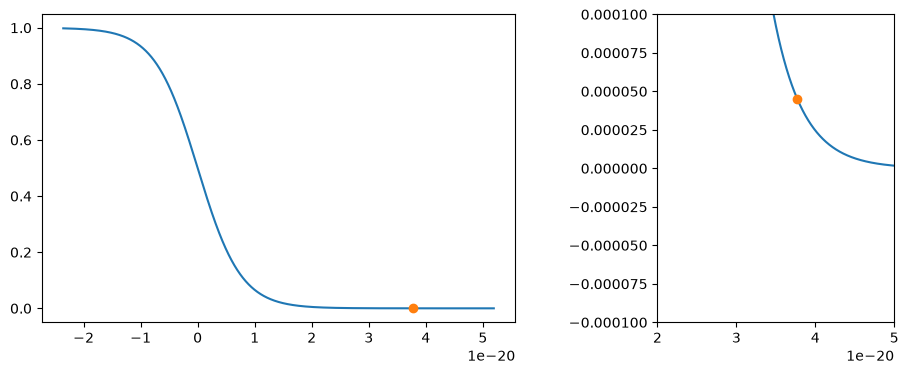

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Перевод энергии Гиббса в размерность Дж/молекула
G_GCG_CTC = 1.02 * 4184 / (6.02 * 10**23)
G_GCG_CGC = (-2.24 - 2.17) * 4184 / (6.02 * 10**23)
delta_mismatch = G_GCG_CTC - G_GCG_CGC
print(f"Разница между двойной спиралью с мисмэтчем и без него равна {delta_mismatch} Дж")

# Расчет P_error
const = 1/(1.380649*(10**(-23))*273) # const - обратная величина к (k_b*T)
'''
Генерируем данные, где^
x(data) - значения 
'''
data = np.linspace(delta_mismatch+2*G_GCG_CGC, delta_mismatch + 2*G_GCG_CTC, 10000)
def P_error(x):
	P = np.exp(-x*const)/(1 + np.exp(-x*const))
	return P
print(f"P_error = {P_error(delta_mismatch)}")

# Создание наглядных графиков
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11,4), gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(wspace=0.4)
ax[0].plot(data, P_error(data))
ax[0].plot(delta_mismatch, P_error(delta_mismatch), marker='o')
ax[1].set_ylim(-0.0001, 0.0001)
ax[1].set_xlim(2*10**(-20), 5*10**(-20))
ax[1].plot(data, P_error(data))
ax[1].plot(delta_mismatch, P_error(delta_mismatch), marker='o')
plt.show()